import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


2__Load the datasets

In [2]:
customers = pd.read_csv("Data/customers.csv")
orders = pd.read_csv("Data/orders.csv")
order_items = pd.read_csv("Data/order_items.csv")
products = pd.read_csv("Data/products.csv")
campaigns = pd.read_csv("Data/marketing_campaigns.csv")
website_events = pd.read_csv("Data/website_events.csv")
support = pd.read_csv("Data/customer_support.csv")
print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
# Keep only completed orders for realized sales analysis

completed_orders = orders[
    orders["order_status"] == "Completed"
].copy()

print(f"Completed orders: {len(completed_orders):,}")

Completed orders: 195,930


Build product-level sales data

In [4]:
sales = order_items.merge(
    products[
        [
            "product_id",
            "product_name",
            "category",
            "sub_category",
            "brand"
        ]
    ],
    on="product_id",
    how="left"
)

sales.head()

,order_id,product_id,quantity,selling_price,cost_price,discount,product_name,category,sub_category,brand
0,ORD0000001,PROD00561,1,1380.24,913.10,185.12,Astra Accessories Model-0561,Electronics,Accessories,Astra
1,ORD0000002,PROD00709,1,972.06,748.74,258.60,BrightHome Storage Model-0709,Home & Kitchen,Storage,BrightHome
2,ORD0000003,PROD00321,1,265.85,223.98,52.96,Trendora Footwear Model-0321,Fashion,Footwear,Trendora
3,ORD0000004,PROD00848,1,716.03,584.16,113.06,PixelPro Laptops Model-0848,Electronics,Laptops,PixelPro
4,ORD0000004,PROD00031,1,2617.53,1886.54,24.41,StreetNine Kids Model-0031,Fashion,Kids,StreetNine


Calculate Revenue

In [5]:
sales["revenue"] = (
    sales["quantity"] *
    sales["selling_price"]
)

Calculate Cost

In [6]:
sales["cost"] = (
    sales["quantity"] *
    sales["cost_price"]
)

profit

In [7]:
sales["profit"] = (
    sales["revenue"] -
    sales["cost"]
)

profit margin

In [8]:
sales["profit_margin"] = (
    sales["profit"] /
    sales["revenue"]
) * 100

In [9]:
sales[
    [
        "product_id",
        "quantity",
        "selling_price",
        "cost_price",
        "revenue",
        "cost",
        "profit",
        "profit_margin"
    ]
].head()

,product_id,quantity,selling_price,cost_price,revenue,cost,profit,profit_margin
0,PROD00561,1,1380.24,913.10,1380.24,913.10,467.14,33.844839
1,PROD00709,1,972.06,748.74,972.06,748.74,223.32,22.973891
2,PROD00321,1,265.85,223.98,265.85,223.98,41.87,15.749483
3,PROD00848,1,716.03,584.16,716.03,584.16,131.87,18.416826
4,PROD00031,1,2617.53,1886.54,2617.53,1886.54,730.99,27.926710


EDA Part 1 — Continue: Revenue Drivers

In [10]:
## Calculate monthly revenue
monthly_revenue = (
    completed_orders
    .groupby(
        completed_orders["order_date"].str[:7]
    )
    .agg(
        revenue=("total_amount", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_id", "nunique")
    )
    .reset_index()
)

monthly_revenue

,order_date,revenue,orders,customers
0,2024-01,44539827.11,8333,7293
1,2024-02,41402813.93,7727,6760
2,2024-03,44515574.60,8352,7295
3,2024-04,43384440.78,8078,7076
4,2024-05,45081153.43,8446,7306
5,2024-06,42588291.75,8017,7026
6,2024-07,43092010.56,8235,7194
7,2024-08,44290259.60,8227,7217
8,2024-09,42508705.20,8079,7047
9,2024-10,45436470.02,8315,7307


In [11]:
##Average Order Value
monthly_revenue["aov"] = (
    monthly_revenue["revenue"] /
    monthly_revenue["orders"]
)

monthly_revenue

,order_date,revenue,orders,customers,aov
0,2024-01,44539827.11,8333,7293,5344.993053
1,2024-02,41402813.93,7727,6760,5358.200327
2,2024-03,44515574.60,8352,7295,5329.929909
3,2024-04,43384440.78,8078,7076,5370.690862
4,2024-05,45081153.43,8446,7306,5337.574406
5,2024-06,42588291.75,8017,7026,5312.247942
6,2024-07,43092010.56,8235,7194,5232.788168
7,2024-08,44290259.60,8227,7217,5383.524930
8,2024-09,42508705.20,8079,7047,5261.629558
9,2024-10,45436470.02,8315,7307,5464.398078


In [12]:
##Orders per Customer
monthly_revenue["orders_per_customer"] = (
    monthly_revenue["orders"] /
    monthly_revenue["customers"]
)

monthly_revenue

,order_date,revenue,orders,customers,aov,orders_per_customer
0,2024-01,44539827.11,8333,7293,5344.993053,1.142602
1,2024-02,41402813.93,7727,6760,5358.200327,1.143047
2,2024-03,44515574.60,8352,7295,5329.929909,1.144894
3,2024-04,43384440.78,8078,7076,5370.690862,1.141605
4,2024-05,45081153.43,8446,7306,5337.574406,1.156036
5,2024-06,42588291.75,8017,7026,5312.247942,1.141048
6,2024-07,43092010.56,8235,7194,5232.788168,1.144704
7,2024-08,44290259.60,8227,7217,5383.524930,1.139947
8,2024-09,42508705.20,8079,7047,5261.629558,1.146445
9,2024-10,45436470.02,8315,7307,5464.398078,1.137950


In [13]:
##Month-over-Month Revenue Growth
monthly_revenue["revenue_growth"] = (
    monthly_revenue["revenue"]
    .pct_change()
    * 100
)

monthly_revenue

,order_date,revenue,orders,customers,aov,orders_per_customer,revenue_growth
0,2024-01,44539827.11,8333,7293,5344.993053,1.142602,NaN
1,2024-02,41402813.93,7727,6760,5358.200327,1.143047,-7.043164
2,2024-03,44515574.60,8352,7295,5329.929909,1.144894,7.518235
3,2024-04,43384440.78,8078,7076,5370.690862,1.141605,-2.540984
4,2024-05,45081153.43,8446,7306,5337.574406,1.156036,3.910878
5,2024-06,42588291.75,8017,7026,5312.247942,1.141048,-5.529720
6,2024-07,43092010.56,8235,7194,5232.788168,1.144704,1.182764
7,2024-08,44290259.60,8227,7217,5383.524930,1.139947,2.780676
8,2024-09,42508705.20,8079,7047,5261.629558,1.146445,-4.022452
9,2024-10,45436470.02,8315,7307,5464.398078,1.137950,6.887448


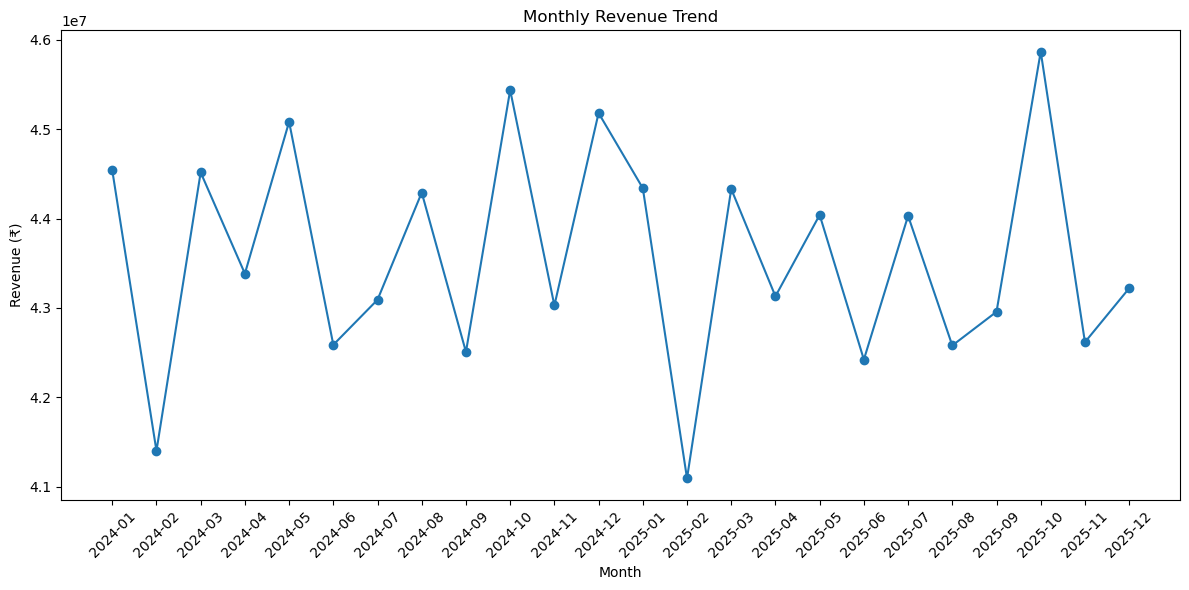

In [14]:
##Revenue Trend
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["order_date"],
    monthly_revenue["revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

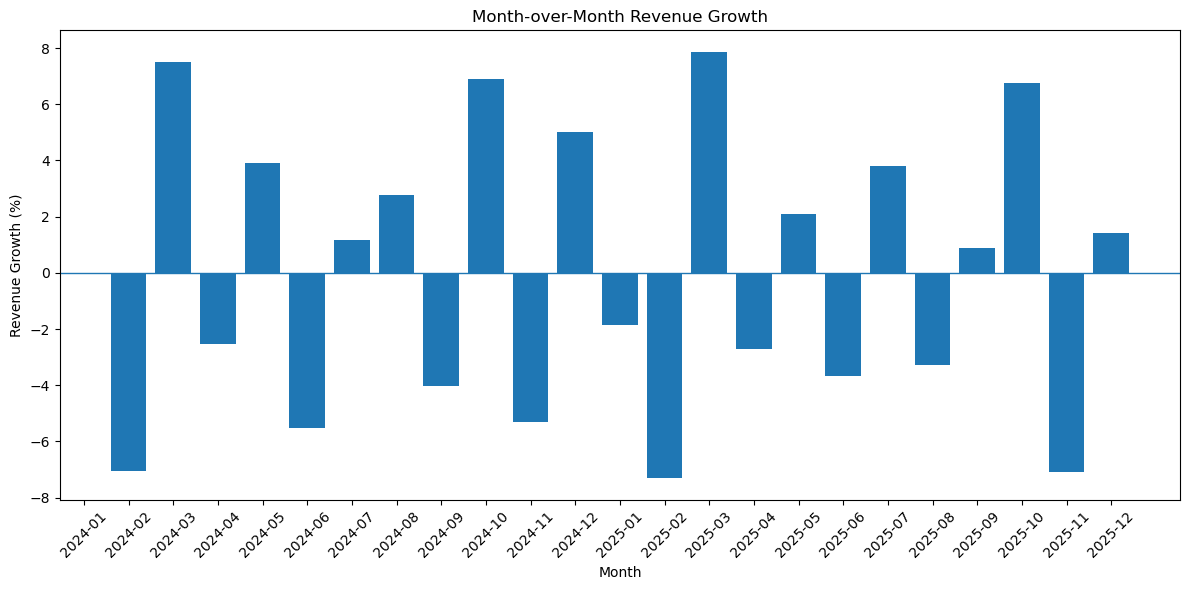

In [15]:
##Revenue Growth
plt.figure(figsize=(12, 6))

plt.bar(
    monthly_revenue["order_date"],
    monthly_revenue["revenue_growth"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("Month-over-Month Revenue Growth")
plt.xlabel("Month")
plt.ylabel("Revenue Growth (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [16]:
##Compare the revenue drivers
monthly_revenue[
    [
        "order_date",
        "revenue",
        "customers",
        "orders_per_customer",
        "aov",
        "revenue_growth"
    ]
]

,order_date,revenue,customers,orders_per_customer,aov,revenue_growth
0,2024-01,44539827.11,7293,1.142602,5344.993053,NaN
1,2024-02,41402813.93,6760,1.143047,5358.200327,-7.043164
2,2024-03,44515574.60,7295,1.144894,5329.929909,7.518235
3,2024-04,43384440.78,7076,1.141605,5370.690862,-2.540984
4,2024-05,45081153.43,7306,1.156036,5337.574406,3.910878
5,2024-06,42588291.75,7026,1.141048,5312.247942,-5.529720
6,2024-07,43092010.56,7194,1.144704,5232.788168,1.182764
7,2024-08,44290259.60,7217,1.139947,5383.524930,2.780676
8,2024-09,42508705.20,7047,1.146445,5261.629558,-4.022452
9,2024-10,45436470.02,7307,1.137950,5464.398078,6.887448


In [17]:
revenue_correlations = (
    monthly_revenue[
        [
            "revenue",
            "customers",
            "orders_per_customer",
            "aov"
        ]
    ]
    .corr()["revenue"]
    .drop("revenue")
    .sort_values(key=abs, ascending=False)
)

revenue_correlations

customers              0.928138
orders_per_customer    0.551878
aov                    0.401120
Name: revenue, dtype: float64

In [18]:
## Highest revenue
monthly_revenue.loc[
    monthly_revenue["revenue"].idxmax()
]

order_date                 2025-10
revenue                45865842.57
orders                        8474
customers                     7368
aov                    5412.537476
orders_per_customer       1.150109
revenue_growth            6.769781
Name: 21, dtype: object

In [19]:
## Lowest revenue
monthly_revenue.loc[
    monthly_revenue["revenue"].idxmin()
]

order_date                 2025-02
revenue                 41094810.5
orders                        7687
customers                     6796
aov                    5346.014115
orders_per_customer       1.131107
revenue_growth           -7.317914
Name: 13, dtype: object

In [20]:
## Highest Growth
monthly_revenue.loc[
    monthly_revenue["revenue_growth"].idxmax()
]

order_date                 2025-03
revenue                 44330490.0
orders                        8288
customers                     7208
aov                    5348.756033
orders_per_customer       1.149834
revenue_growth            7.873694
Name: 14, dtype: object

In [21]:
## Biggest Decline
monthly_revenue.loc[
    monthly_revenue["revenue_growth"].idxmin()
]

order_date                 2025-02
revenue                 41094810.5
orders                        7687
customers                     6796
aov                    5346.014115
orders_per_customer       1.131107
revenue_growth           -7.317914
Name: 13, dtype: object

Analysisi:- "Monthly customer volume shows the strongest association with revenue (r = 0.928), substantially higher than purchase frequency (r = 0.552) and AOV (r = 0.401). This suggests that customer acquisition/activation is the primary revenue lever observed in the dataset."

EDA Part 1 — One more analysis
Is the business growing because it is acquiring more customers, or because existing customers are purchasing more?

Customer growth vs revenue growth


In [22]:
monthly_revenue["customer_growth"] = (
    monthly_revenue["customers"]
    .pct_change() * 100
)

monthly_revenue[
    [
        "order_date",
        "revenue_growth",
        "customer_growth",
        "orders_per_customer",
        "aov"
    ]
]

,order_date,revenue_growth,customer_growth,orders_per_customer,aov
0,2024-01,NaN,NaN,1.142602,5344.993053
1,2024-02,-7.043164,-7.308378,1.143047,5358.200327
2,2024-03,7.518235,7.914201,1.144894,5329.929909
3,2024-04,-2.540984,-3.002056,1.141605,5370.690862
4,2024-05,3.910878,3.250424,1.156036,5337.574406
5,2024-06,-5.529720,-3.832466,1.141048,5312.247942
6,2024-07,1.182764,2.391119,1.144704,5232.788168
7,2024-08,2.780676,0.319711,1.139947,5383.524930
8,2024-09,-4.022452,-2.355549,1.146445,5261.629558
9,2024-10,6.887448,3.689513,1.137950,5464.398078


In [23]:
monthly_revenue[
    [
        "revenue_growth",
        "customer_growth"
    ]
].corr()


,revenue_growth,customer_growth
revenue_growth,1.000000,0.953745
customer_growth,0.953745,1.000000


EDA Part 2 — Customer Value & Acquisition Quality
We'll determine which acquisition channel brings customers who actually generate revenue and repeat purchases

In [24]:
##Connect customers with their order behavior

customer_orders = (
    completed_orders
    .groupby("customer_id")
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("total_amount", "sum"),
        first_order_date=("order_date", "min"),
        last_order_date=("order_date", "max")
    )
    .reset_index()
)

customer_orders.head()

,customer_id,total_orders,total_revenue,first_order_date,last_order_date
0,CUST000001,5,19158.74,2024-03-16,2025-12-09
1,CUST000002,2,3186.76,2024-07-28,2024-08-01
2,CUST000003,12,54412.98,2024-02-20,2025-11-28
3,CUST000004,6,40855.80,2024-04-04,2025-10-16
4,CUST000005,1,4645.89,2025-12-30,2025-12-30


In [25]:
##Add customer information
customer_value = customers.merge(
    customer_orders,
    on="customer_id",
    how="left"
)

customer_value.head()

,customer_id,signup_date,gender,age,city,state,acquisition_channel,customer_type,income_band,total_orders,total_revenue,first_order_date,last_order_date
0,CUST000001,2024-02-29,Non-binary,33,Chandigarh,Chandigarh,Email,Loyal,Middle,5.0,19158.74,2024-03-16,2025-12-09
1,CUST000002,2025-06-01,Male,34,Hyderabad,Telangana,Email,Returning,Upper-Middle,2.0,3186.76,2024-07-28,2024-08-01
2,CUST000003,2025-03-13,Male,19,Ahmedabad,Gujarat,Referral,Loyal,Lower-Middle,12.0,54412.98,2024-02-20,2025-11-28
3,CUST000004,2024-10-20,Female,38,Bengaluru,Karnataka,Referral,Loyal,Upper-Middle,6.0,40855.80,2024-04-04,2025-10-16
4,CUST000005,2024-10-16,Male,42,Ahmedabad,Gujarat,Google Ads,New,Middle,1.0,4645.89,2025-12-30,2025-12-30


In [26]:
##Handle customers with no completed orders
customer_value["total_orders"] = (
    customer_value["total_orders"]
    .fillna(0)
)

customer_value["total_revenue"] = (
    customer_value["total_revenue"]
    .fillna(0)
)

In [27]:
## Calculate customer-level AOV
customer_value["customer_aov"] = np.where(
    customer_value["total_orders"] > 0,
    customer_value["total_revenue"] /
    customer_value["total_orders"],
    0
)

In [28]:
## Analyze acquisition channels
# Which acquisition channel brings the most valuable customers?

channel_performance = (
    customer_value
    .groupby("acquisition_channel")
    .agg(
        customers=("customer_id", "nunique"),
        revenue=("total_revenue", "sum"),
        orders=("total_orders", "sum")
    )
    .reset_index()
)

channel_performance

,acquisition_channel,customers,revenue,orders
0,Affiliate,6017,1.249588e+08,23395.0
1,Email,4948,1.079550e+08,20211.0
2,Google Ads,10000,2.104245e+08,39204.0
3,Instagram,8974,1.870876e+08,35170.0
4,Organic Search,12647,2.616794e+08,49361.0
5,Referral,7414,1.535745e+08,28589.0


In [29]:
## Calculate revenue per customer

channel_performance["revenue_per_customer"] = (
    channel_performance["revenue"] /
    channel_performance["customers"]
)

In [30]:
## Calculate orders per customer

channel_performance["orders_per_customer"] = (
    channel_performance["orders"] /
    channel_performance["customers"]
)

In [31]:
## Sort by customer value

channel_performance.sort_values(
    "revenue_per_customer",
    ascending=False
)

,acquisition_channel,customers,revenue,orders,revenue_per_customer,orders_per_customer
1,Email,4948,1.079550e+08,20211.0,21817.913941,4.084681
2,Google Ads,10000,2.104245e+08,39204.0,21042.452326,3.920400
3,Instagram,8974,1.870876e+08,35170.0,20847.738110,3.919100
0,Affiliate,6017,1.249588e+08,23395.0,20767.628885,3.888150
5,Referral,7414,1.535745e+08,28589.0,20714.116211,3.856083
4,Organic Search,12647,2.616794e+08,49361.0,20691.027200,3.902981


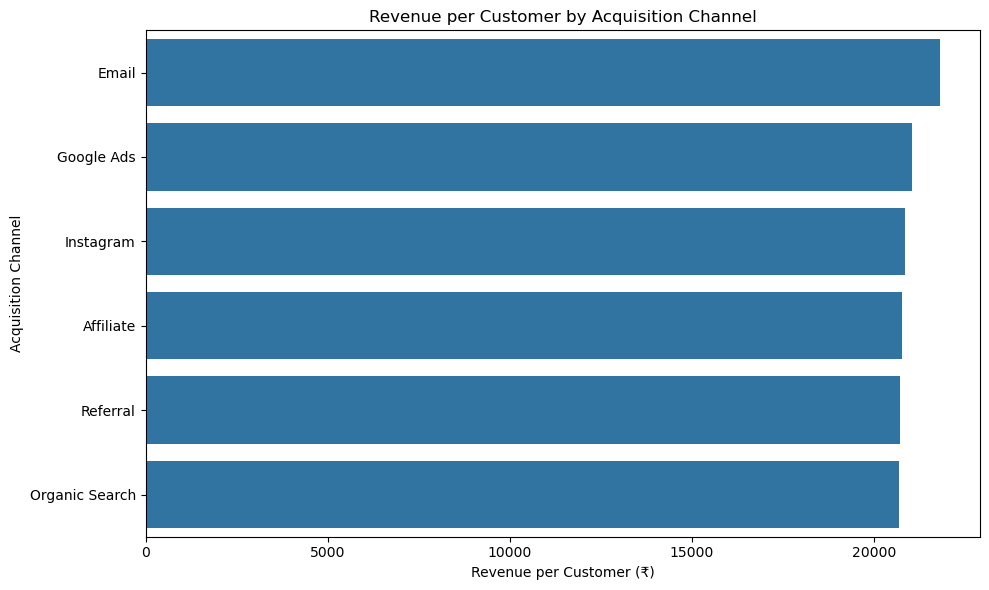

In [32]:
## Visualize channel quality

plt.figure(figsize=(10, 6))

sns.barplot(
    data=channel_performance.sort_values(
        "revenue_per_customer",
        ascending=False
    ),
    x="revenue_per_customer",
    y="acquisition_channel"
)

plt.title("Revenue per Customer by Acquisition Channel")
plt.xlabel("Revenue per Customer (₹)")
plt.ylabel("Acquisition Channel")

plt.tight_layout()
plt.show()

Finding #1 — Acquisition volume ≠ customer quality
Organic Search brings the most customers:- 12,647 customers, and the highest total revenue:- ₹261.7M
But Email has the highest revenue per customer:- ₹21,818/customer

So if management only looks at total revenue, Organic Search looks like the winner.

But if management looks at customer value, Email is the winner.



In [33]:
## Organic Search is the largest acquisition channel by customer volume and total revenue, while Email generates the highest revenue per customer. This indicates that acquisition-channel performance should be evaluated on customer quality as well as acquisition scale.

EDA Part 2B — Channel Profitability

In [34]:
# Add customer acquisition channel to sales
sales_with_channel = (
    sales
    .merge(
        completed_orders[
            ["order_id", "customer_id"]
        ],
        on="order_id",
        how="inner"
    )
    .merge(
        customers[
            ["customer_id", "acquisition_channel"]
        ],
        on="customer_id",
        how="left"
    )
)

sales_with_channel.head()

,order_id,product_id,quantity,selling_price,cost_price,discount,product_name,category,sub_category,brand,revenue,cost,profit,profit_margin,customer_id,acquisition_channel
0,ORD0000001,PROD00561,1,1380.24,913.10,185.12,Astra Accessories Model-0561,Electronics,Accessories,Astra,1380.24,913.10,467.14,33.844839,CUST010027,Instagram
1,ORD0000002,PROD00709,1,972.06,748.74,258.60,BrightHome Storage Model-0709,Home & Kitchen,Storage,BrightHome,972.06,748.74,223.32,22.973891,CUST008221,Organic Search
2,ORD0000003,PROD00321,1,265.85,223.98,52.96,Trendora Footwear Model-0321,Fashion,Footwear,Trendora,265.85,223.98,41.87,15.749483,CUST025983,Google Ads
3,ORD0000004,PROD00848,1,716.03,584.16,113.06,PixelPro Laptops Model-0848,Electronics,Laptops,PixelPro,716.03,584.16,131.87,18.416826,CUST032537,Organic Search
4,ORD0000004,PROD00031,1,2617.53,1886.54,24.41,StreetNine Kids Model-0031,Fashion,Kids,StreetNine,2617.53,1886.54,730.99,27.926710,CUST032537,Organic Search


In [35]:
# Calculate channel profitability
channel_profitability = (
    sales_with_channel
    .groupby("acquisition_channel")
    .agg(
        revenue=("revenue", "sum"),
        profit=("profit", "sum"),
        customers=("customer_id", "nunique"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

In [36]:
# Calculate profit margin
channel_profitability["profit_margin"] = (
    channel_profitability["profit"] /
    channel_profitability["revenue"]
) * 100


# And profit per customer:
channel_profitability["profit_per_customer"] = (
    channel_profitability["profit"] /
    channel_profitability["customers"]
)


In [37]:
 # Sort by profitability

channel_profitability.sort_values(
    "profit_per_customer",
    ascending=False)

,acquisition_channel,revenue,profit,customers,orders,profit_margin,profit_per_customer
1,Email,1.079550e+08,36670022.43,4195,20211,33.967866,8741.364107
2,Google Ads,2.104245e+08,71517904.06,8457,39204,33.987438,8456.651775
3,Instagram,1.870876e+08,63647203.15,7563,35170,34.020001,8415.602691
5,Referral,1.535745e+08,52418961.85,6229,28589,34.132604,8415.309335
0,Affiliate,1.249588e+08,42327384.28,5054,23395,33.873066,8375.026569
4,Organic Search,2.616794e+08,88827006.81,10715,49361,33.944972,8289.967971


EDA Finding #2 — Acquisition Channel Profitability

Organic Search is the scale leader:
Highest revenue: ₹261.68M AND Highest total profit: ₹88.27M
Highest number of customers in this completed-order analysis: 10,715
But Email produces the highest profit per customer:- ₹8,741/customer
while Organic Search produces:- ₹8,290/customer

That's a difference of about ₹451 per customer.

In [38]:
# Organic Search is the strongest acquisition channel by scale, generating the highest total revenue and profit. However, Email generates the highest profit per customer, indicating stronger customer economics at the individual level. Therefore, acquisition performance should be evaluated using both scale and customer-level profitability rather than revenue alone.
print("If the objective is:") 
print("1.Maximum total profit → Organic Search" )
print("2.Maximum profit per customer → Email")

If the objective is:
1.Maximum total profit → Organic Search
2.Maximum profit per customer → Email


EDA Part 3 — Customer Retention

Do customers acquired through different channels behave differently after their first purchase?


In [39]:
# Identify repeat customers

customer_repeat = (
    completed_orders
    .groupby("customer_id")
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("total_amount", "sum")
    )
    .reset_index()
)

customer_repeat["is_repeat_customer"] = (
    customer_repeat["total_orders"] > 1
)

customer_repeat.head()

,customer_id,total_orders,total_revenue,is_repeat_customer
0,CUST000001,5,19158.74,True
1,CUST000002,2,3186.76,True
2,CUST000003,12,54412.98,True
3,CUST000004,6,40855.80,True
4,CUST000005,1,4645.89,False


In [40]:
# Calculate overall repeat-purchase rate
repeat_rate = (
    customer_repeat["is_repeat_customer"].mean()
    * 100
)

print(f"Repeat Purchase Rate: {repeat_rate:.2f}%")

Repeat Purchase Rate: 81.06%


In [41]:
# Connect repeat behavior to acquisition channel
customer_repeat_channel = customer_repeat.merge(
    customers[
        ["customer_id", "acquisition_channel"]
    ],
    on="customer_id",
    how="left"
)

customer_repeat_channel.head()

,customer_id,total_orders,total_revenue,is_repeat_customer,acquisition_channel
0,CUST000001,5,19158.74,True,Email
1,CUST000002,2,3186.76,True,Email
2,CUST000003,12,54412.98,True,Referral
3,CUST000004,6,40855.80,True,Referral
4,CUST000005,1,4645.89,False,Google Ads


In [42]:
# Calculate repeat rate by channel

channel_repeat = (
    customer_repeat_channel
    .groupby("acquisition_channel")
    .agg(
        customers=("customer_id", "nunique"),
        repeat_customers=("is_repeat_customer", "sum"),
        avg_orders=("total_orders", "mean"),
        avg_revenue=("total_revenue", "mean")
    )
    .reset_index()
)

In [43]:
# Calculate repeat percentage
channel_repeat["repeat_rate"] = (
    channel_repeat["repeat_customers"] /
    channel_repeat["customers"]
) * 100
 # now sort
channel_repeat.sort_values(
    "repeat_rate",
    ascending=False
)

,acquisition_channel,customers,repeat_customers,avg_orders,avg_revenue,repeat_rate
3,Instagram,7563,6173,4.650271,24737.220918,81.621050
0,Affiliate,5054,4107,4.629007,24724.737436,81.262366
2,Google Ads,8457,6860,4.635686,24881.698387,81.116235
1,Email,4195,3401,4.817878,25734.216491,81.072706
4,Organic Search,10715,8684,4.606720,24421.784508,81.045264
5,Referral,6229,4992,4.589661,24654.753185,80.141275


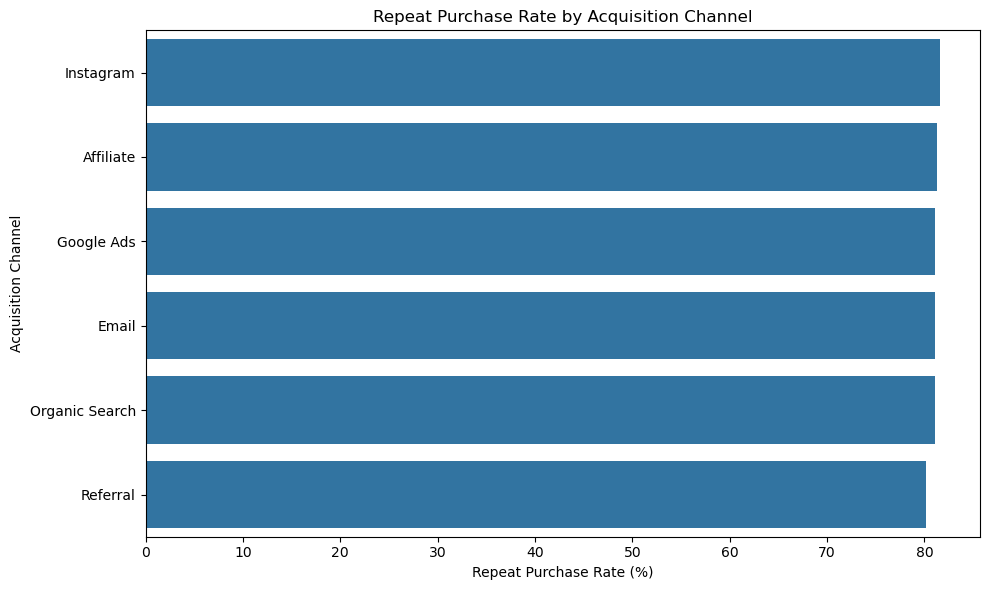

In [44]:
# Visualize repeat rate
plt.figure(figsize=(10, 6))

sns.barplot(
    data=channel_repeat.sort_values(
        "repeat_rate",
        ascending=False
    ),
    x="repeat_rate",
    y="acquisition_channel"
)

plt.title("Repeat Purchase Rate by Acquisition Channel")
plt.xlabel("Repeat Purchase Rate (%)")
plt.ylabel("Acquisition Channel")

plt.tight_layout()
plt.show()

EDA Finding #3 — Retention is surprisingly consistent
1. Instagram has the highest repeat rate :- 81.62%
2. Referral has the lowest repeat rate :- 80.14%
The gap between Instagram and Referral is:- 81.62 − 80.14 = 1.48 percentage points
So the channels are actually quite close.
We should therefore not claim that Instagram dramatically outperforms Referral.

3. Email is particularly interesting
Email has:- Highest average orders: 4.82
Highest average revenue: ₹25,734
But repeat rate: 81.07%

Email customers don't have the highest repeat rate, but the customers who do purchase repeatedly appear to generate stronger overall customer value.

In [45]:
## Repeat-purchase rates are relatively consistent across acquisition channels, ranging from 80.14% to 81.62%. However, Email customers demonstrate the highest average order frequency (4.82) and average revenue (₹25.7K), suggesting that customer quality may be more differentiated by purchase intensity than by repeat-purchase probability alone.

EDA Part 4 — Customer Recency & Revenue-at-Risk

In [46]:
# Convert dates to datetime
completed_orders["order_date"] = pd.to_datetime(
    completed_orders["order_date"]
)

# Find latest order date
latest_order_date = completed_orders["order_date"].max()

print("Latest completed order:", latest_order_date)

Latest completed order: 2025-12-30 00:00:00


In [47]:
# Calculate customer recency
customer_recency = (
    completed_orders
    .groupby("customer_id")
    .agg(
        last_order_date=("order_date", "max"),
        total_orders=("order_id", "nunique"),
        total_revenue=("total_amount", "sum")
    )
    .reset_index()
)

customer_recency["recency_days"] = (
    latest_order_date -
    customer_recency["last_order_date"]
).dt.days

customer_recency.head()

,customer_id,last_order_date,total_orders,total_revenue,recency_days
0,CUST000001,2025-12-09,5,19158.74,21
1,CUST000002,2024-08-01,2,3186.76,516
2,CUST000003,2025-11-28,12,54412.98,32
3,CUST000004,2025-10-16,6,40855.80,75
4,CUST000005,2025-12-30,1,4645.89,0


In [48]:
# Look at the recency distribution
customer_recency["recency_days"].describe()

count    42213.000000
mean       185.860422
std        176.818108
min          0.000000
25%         48.000000
50%        124.000000
75%        276.000000
max        729.000000
Name: recency_days, dtype: float64

In [49]:
# Create Recency Segments
customer_recency["recency_segment"] = pd.cut(
    customer_recency["recency_days"],
    bins=[-1, 48, 124, 276, float("inf")],
    labels=[
        "Very Recent",
        "Recent",
        "At Risk",
        "Inactive"
    ]
)

customer_recency["recency_segment"].value_counts(
    sort=False
)

recency_segment
Very Recent    10660
Recent         10448
At Risk        10586
Inactive       10519
Name: count, dtype: int64

In [50]:
# Calculate revenue at risk
recency_value = customer_recency.copy()

recency_value["revenue_at_risk"] = np.where(
    recency_value["recency_segment"].isin(
        ["At Risk", "Inactive"]
    ),
    recency_value["total_revenue"],
    0
)

In [51]:
# Now calculate the total:
total_revenue_at_risk = (
    recency_value["revenue_at_risk"].sum()
)

print(
    f"Revenue at Risk: "
    f"₹{total_revenue_at_risk:,.2f}"
)

Revenue at Risk: ₹337,805,560.24


In [52]:
# How many customers are at risk?
at_risk_customers = recency_value[
    recency_value["recency_segment"].isin(
        ["At Risk", "Inactive"]
    )
]

print(
    "Customers at risk:",
    len(at_risk_customers)
)

Customers at risk: 21105


In [53]:
at_risk_percentage = (
    len(at_risk_customers) /
    len(recency_value)
) * 100

print(
    f"At-risk customer percentage: "
    f"{at_risk_percentage:.2f}%"
)

At-risk customer percentage: 50.00%


In [54]:
#See revenue by recency segment
recency_summary = (
    recency_value
    .groupby("recency_segment", observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        revenue=("total_revenue", "sum"),
        avg_revenue=("total_revenue", "mean"),
        avg_orders=("total_orders", "mean")
    )
    .reset_index()
)

recency_summary

,recency_segment,customers,revenue,avg_revenue,avg_orders
0,Very Recent,10660,3.988177e+08,37412.543436,7.021295
1,Recent,10448,3.090566e+08,29580.454782,5.540199
2,At Risk,10586,2.205425e+08,20833.415128,3.921783
3,Inactive,10519,1.172630e+08,11147.735308,2.061318


EDA Finding #4 — Revenue-at-Risk
The important discovery
Your At Risk + Inactive customers are:- 10,586 + 10,519 = 21,105 customers
Out of:- 42,213 customers
So approximately 50% of customers fall into the At Risk/Inactive groups.
And their historical revenue is approximately:- ₹220.54M + ₹117.26M = ₹337.81M

EDA Part 4B — Identify High-Value Customers at Risk

In [55]:
#Calculate customer revenue percentiles
customer_recency["revenue_percentile"] = (
    customer_recency["total_revenue"]
    .rank(pct=True)
)

In [57]:
#Define high-value customers
#We will define high-value customers using the top 20% of customer revenue.
high_value_threshold = (
    customer_recency["total_revenue"]
    .quantile(0.80)
)

print(
    f"High-value customer threshold: "
    f"₹{high_value_threshold:,.2f}"
)

High-value customer threshold: ₹39,637.30


In [59]:
#Identify high-value customers at risk
high_value_at_risk = customer_recency[
    (
        customer_recency["total_revenue"]
        >= high_value_threshold
    )
    &
    (
        customer_recency["recency_days"]
        > 124
    )
].copy()
#Why >124?-->>> Because your median recency is 124 days, so we're identifying high-value customers whose inactivity is worse than the typical customer.

In [60]:
# Measure the opportunity
print(
    "High-value customers at risk:",
    len(high_value_at_risk)
)

print(
    f"Historical revenue exposure: "
    f"₹{high_value_at_risk['total_revenue'].sum():,.2f}"
)

High-value customers at risk: 1751
Historical revenue exposure: ₹97,554,501.47


In [61]:
# See the most valuable at-risk customers
high_value_at_risk[
    [
        "customer_id",
        "total_orders",
        "total_revenue",
        "last_order_date",
        "recency_days"
    ]
].sort_values(
    "total_revenue",
    ascending=False
).head(20)

,customer_id,total_orders,total_revenue,last_order_date,recency_days
1297,CUST001503,22,180471.69,2025-06-23,190
13706,CUST016189,21,170488.73,2025-06-30,183
34969,CUST041419,16,153232.46,2025-08-17,135
18198,CUST021506,10,150390.67,2025-07-25,158
26112,CUST030877,8,143453.68,2025-05-04,240
5188,CUST006131,13,142255.99,2025-08-23,129
13073,CUST015440,19,140847.09,2025-08-04,148
39271,CUST046506,9,140490.35,2025-08-10,142
25607,CUST030252,16,137992.72,2025-08-19,133
17851,CUST021095,14,129942.68,2025-07-30,153


High-value threshold: ₹39,637.30
High-value customers at risk: 1,751
Historical revenue exposure: ₹97.55M
That means 1,751 customers who belong to the top 20% by historical customer revenue have gone beyond the median recency threshold.


The analysis identified 1,751 high-value customers with purchase recency above the dataset median, representing ₹97.55M in historical revenue exposure. These customers should be prioritized for targeted retention initiatives because they combine high historical value with declining engagement.

In [62]:
#Create Recency Risk Score
#Higher recency = higher risk.
customer_recency["recency_risk_score"] = (
    customer_recency["recency_days"]
    .rank(pct=True) * 100
)

In [ ]:
# Create Customer Value Score
customer_recency["value_score"] = (
    customer_recency["total_revenue"]
    .rank(pct=True) * 100
)
# Low-value customer → low score
# High-value customer → high score

In [67]:
# Create Purchase Frequency Score
# Customers with more historical orders have stronger demonstrated engagement.
customer_recency["frequency_score"] = (
    customer_recency["total_orders"]
    .rank(pct=True) * 100
)

In [66]:
# Create Customer Priority Score
customer_recency["priority_score"] = (
    customer_recency["recency_risk_score"] * 0.50
    +
    customer_recency["value_score"] * 0.30
    +
    customer_recency["frequency_score"] * 0.20
)

In [68]:
# Create priority categories
customer_recency["priority_segment"] = pd.cut(
    customer_recency["priority_score"],
    bins=[-1, 50, 70, 85, 100],
    labels=[
        "Low Priority",
        "Medium Priority",
        "High Priority",
        "Critical Priority"
    ]
)

In [69]:
# Examine the result
priority_summary = (
    customer_recency
    .groupby(
        "priority_segment",
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        revenue=("total_revenue", "sum"),
        avg_revenue=("total_revenue", "mean"),
        avg_recency=("recency_days", "mean"),
        avg_orders=("total_orders", "mean")
    )
    .reset_index()
)

priority_summary

,priority_segment,customers,revenue,avg_revenue,avg_recency,avg_orders
0,Low Priority,19532,3.196322e+08,16364.538189,108.408253,3.588982
1,Medium Priority,20025,6.013548e+08,30030.201314,248.053233,5.365144
2,High Priority,2630,1.228259e+08,46701.846369,285.622814,6.908365
3,Critical Priority,26,1.867068e+06,71810.294615,378.538462,8.615385


In [70]:
# Find your most important customers
critical_customers = customer_recency[
    customer_recency["priority_segment"]
    == "Critical Priority"
].copy()

critical_customers = critical_customers.sort_values(
    "priority_score",
    ascending=False
)

critical_customers[
    [
        "customer_id",
        "total_orders",
        "total_revenue",
        "last_order_date",
        "recency_days",
        "priority_score"
    ]
].head(20)

,customer_id,total_orders,total_revenue,last_order_date,recency_days,priority_score
16293,CUST019255,9,118694.06,2025-01-02,362,88.999242
444,CUST000527,11,100754.20,2025-02-01,332,88.537180
18081,CUST021374,9,48963.63,2024-09-20,466,88.505081
19993,CUST023638,10,102612.83,2025-02-10,323,87.698932
18765,CUST022178,12,96931.92,2025-02-26,307,87.573852
42026,CUST049785,10,47523.36,2024-11-06,419,87.414541
40247,CUST047664,8,62362.05,2024-12-02,393,87.306635
37116,CUST043927,8,55820.01,2024-11-11,414,87.193045
25850,CUST030558,8,77339.89,2025-01-20,344,86.550115
39935,CUST047284,6,61035.40,2024-10-15,441,86.497761


EDA Finding #5 — Customer Priority Segmentation
Only 26 customers are classified as Critical.
Average historical revenue: ₹71,810
Average orders: 8.62
Average recency: 379 days

The customer-priority model identified a small group of 26 critical customers with an average historical value of ₹71.8K and 8.6 orders per customer, but an average purchase gap of 379 days. These customers represent a concentrated high-value retention opportunity

In [71]:
#Calculate the revenue concentration
critical_revenue = (
    critical_customers["total_revenue"].sum()
)

total_customer_revenue = (
    customer_recency["total_revenue"].sum()
)

critical_revenue_share = (
    critical_revenue /
    total_customer_revenue
) * 100

print(f"Critical customer revenue: ₹{critical_revenue:,.2f}")
print(f"Total customer revenue: ₹{total_customer_revenue:,.2f}")
print(f"Revenue concentration: {critical_revenue_share:.2f}%")

Critical customer revenue: ₹1,867,067.66
Total customer revenue: ₹1,045,679,864.83
Revenue concentration: 0.18%


In [72]:
# Identify the acquisition channels of Critical customers
critical_with_channel = critical_customers.merge(
    customers[
        ["customer_id", "acquisition_channel"]
    ],
    on="customer_id",
    how="left"
)

critical_channel = (
    critical_with_channel
    .groupby("acquisition_channel")
    .agg(
        critical_customers=("customer_id", "nunique"),
        historical_revenue=("total_revenue", "sum"),
        avg_revenue=("total_revenue", "mean"),
        avg_recency=("recency_days", "mean")
    )
    .reset_index()
    .sort_values(
        "historical_revenue",
        ascending=False
    )
)

critical_channel

,acquisition_channel,critical_customers,historical_revenue,avg_revenue,avg_recency
4,Organic Search,8,661670.74,82708.842500,362.125000
2,Google Ads,6,410386.18,68397.696667,372.333333
3,Instagram,5,320647.08,64129.416000,378.000000
5,Referral,3,240988.12,80329.373333,369.333333
0,Affiliate,2,126819.09,63409.545000,418.500000
1,Email,2,106556.45,53278.225000,438.000000


Organic Search produced the largest number of Critical customers and the highest total historical revenue among the Critical segment.

In [73]:
 # Look at the critical customers themselves
critical_customers[
    [
        "customer_id",
        "total_orders",
        "total_revenue",
        "last_order_date",
        "recency_days",
        "priority_score"
    ]
].sort_values(
    "total_revenue",
    ascending=False
)

,customer_id,total_orders,total_revenue,last_order_date,recency_days,priority_score
16293,CUST019255,9,118694.06,2025-01-02,362,88.999242
41732,CUST049433,9,109248.77,2025-03-01,304,86.215858
19993,CUST023638,10,102612.83,2025-02-10,323,87.698932
444,CUST000527,11,100754.20,2025-02-01,332,88.537180
32370,CUST038293,6,98927.18,2025-01-09,355,85.518798
18765,CUST022178,12,96931.92,2025-02-26,307,87.573852
5556,CUST006556,12,91746.60,2025-04-11,263,85.124843
39513,CUST046793,9,88149.68,2025-03-09,296,85.378793
12804,CUST015131,14,83605.20,2025-04-09,265,85.439793
4667,CUST005515,5,79295.73,2024-11-07,418,85.483974


Critical customers are financially concentrated differently than the broader high-value-at-risk group

Your 26 Critical Priority customers generated:- ₹1,867,067.66 historical revenue
out of total customer revenue:- ₹1,045,679,864.83
So their revenue concentration is only:- 0.18%



In [75]:
critical_customers.to_csv(
    "Data/critical_customers.csv",
    index=False
)

print("Critical customer file saved successfully.")
print(f"Customers saved: {len(critical_customers):,}")

Critical customer file saved successfully.
Customers saved: 26
